<a href="https://colab.research.google.com/github/GEO-HACK/watchtower-ml/blob/main/notebooks/random_trainer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
os.listdir('/content/drive/MyDrive/CICIDS')

['X_train.npy',
 'X_test.npy',
 'y_train.npy',
 'y_test.npy',
 'preprocessing_pipeline.pkl',
 'label_encoder.pkl',
 'rf_feature_importance.png',
 'rf_per_class_f1.png',
 'rf_confusion_matrix.png']

In [6]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
    f1_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("imports done")

imports done


loading the data

In [7]:
BASE = '/content/drive/MyDrive/CICIDS/'

X_train = np.load(BASE + 'X_train.npy')
X_test  = np.load(BASE + 'X_test.npy')
y_train = np.load(BASE + 'y_train.npy')
y_test  = np.load(BASE + 'y_test.npy')

# .pkl for fitted objects
le       = joblib.load(BASE + 'label_encoder.pkl')
pipeline = joblib.load(BASE + 'preprocessing_pipeline.pkl')

In [8]:
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")

X_train shape : (1725584, 68)
X_test shape  : (431397, 68)


Model definition

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth = None,
    min_samples_split=10,
    min_samples_leaf=5,

    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

In [10]:
# print("Running stratified k-fold cv( k=5) ...")

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# cv_scores = cross_val_score(
#     rf,X_train,y_train,cv=cv,scoring='f1_macro',
#     n_jobs=-1
# )

# print(f"\nCV Macro F1 per fold : {cv_scores.round(4)}")
# print(f"Mean  : {cv_scores.mean():.4f}")
# print(f"Std   : {cv_scores.std():.4f}")

In [11]:
print("Training Random Forest on full training set...")

rf.fit(X_train, y_train)

print("✅ Training complete")

Training Random Forest on full training set...
✅ Training complete


perform evaluation opn test data

In [12]:
y_pred = rf.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Overall Macro F1: {macro_f1:.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    346659
           1       0.70      0.97      0.81       390
           2       1.00      1.00      1.00     25603
           3       0.99      1.00      0.99      2057
           4       1.00      1.00      1.00     34570
           5       1.00      0.99      0.99      1046
           6       0.99      0.99      0.99      1077
           7       1.00      1.00      1.00      1187
           8       1.00      1.00      1.00     18164
           9       1.00      1.00      1.00       644

    accuracy                           1.00    431397
   macro avg       0.97      0.99      0.98    431397
weighted avg       1.00      1.00      1.00    431397

Overall Macro F1: 0.9791


In [13]:
from sklearn.metrics import precision_recall_fscore_support

# Isolate Bot performance
bot_idx = list(le.classes_).index('Bot')

# Find all Bot test samples
bot_mask      = y_test == bot_idx
bot_true      = y_test[bot_mask]
bot_predicted = y_pred[bot_mask]

# Where did the model go wrong on Bot?
print("=== Bot Class Analysis ===")
print(f"Total Bot test samples : {bot_mask.sum()}")
print(f"Correctly identified   : {(bot_predicted == bot_idx).sum()}")
print(f"Missed (false negatives): {(bot_predicted != bot_idx).sum()}")

# What did the model predict instead of Bot?
misclassified = bot_predicted[bot_predicted != bot_idx]
if len(misclassified) > 0:
    print("\nMissed Bot samples were predicted as:")
    unique_wrong, wrong_counts = np.unique(misclassified, return_counts=True)
    for cls, cnt in zip(le.inverse_transform(unique_wrong), wrong_counts):
        print(f"  → {cls:<22} : {cnt} times")

# Also check what was incorrectly predicted AS Bot (false positives)
false_positives = (y_pred == bot_idx) & (y_test != bot_idx)
print(f"\nFalse positives (other classes predicted as Bot): {false_positives.sum()}")
if false_positives.sum() > 0:
    fp_true_labels = y_test[false_positives]
    unique_fp, fp_counts = np.unique(fp_true_labels, return_counts=True)
    for cls, cnt in zip(le.inverse_transform(unique_fp), fp_counts):
        print(f"  → {cls:<22} : {cnt} times")

=== Bot Class Analysis ===
Total Bot test samples : 390
Correctly identified   : 378
Missed (false negatives): 12

Missed Bot samples were predicted as:
  → BENIGN                 : 12 times

False positives (other classes predicted as Bot): 161
  → BENIGN                 : 161 times


the cinfusion matrix

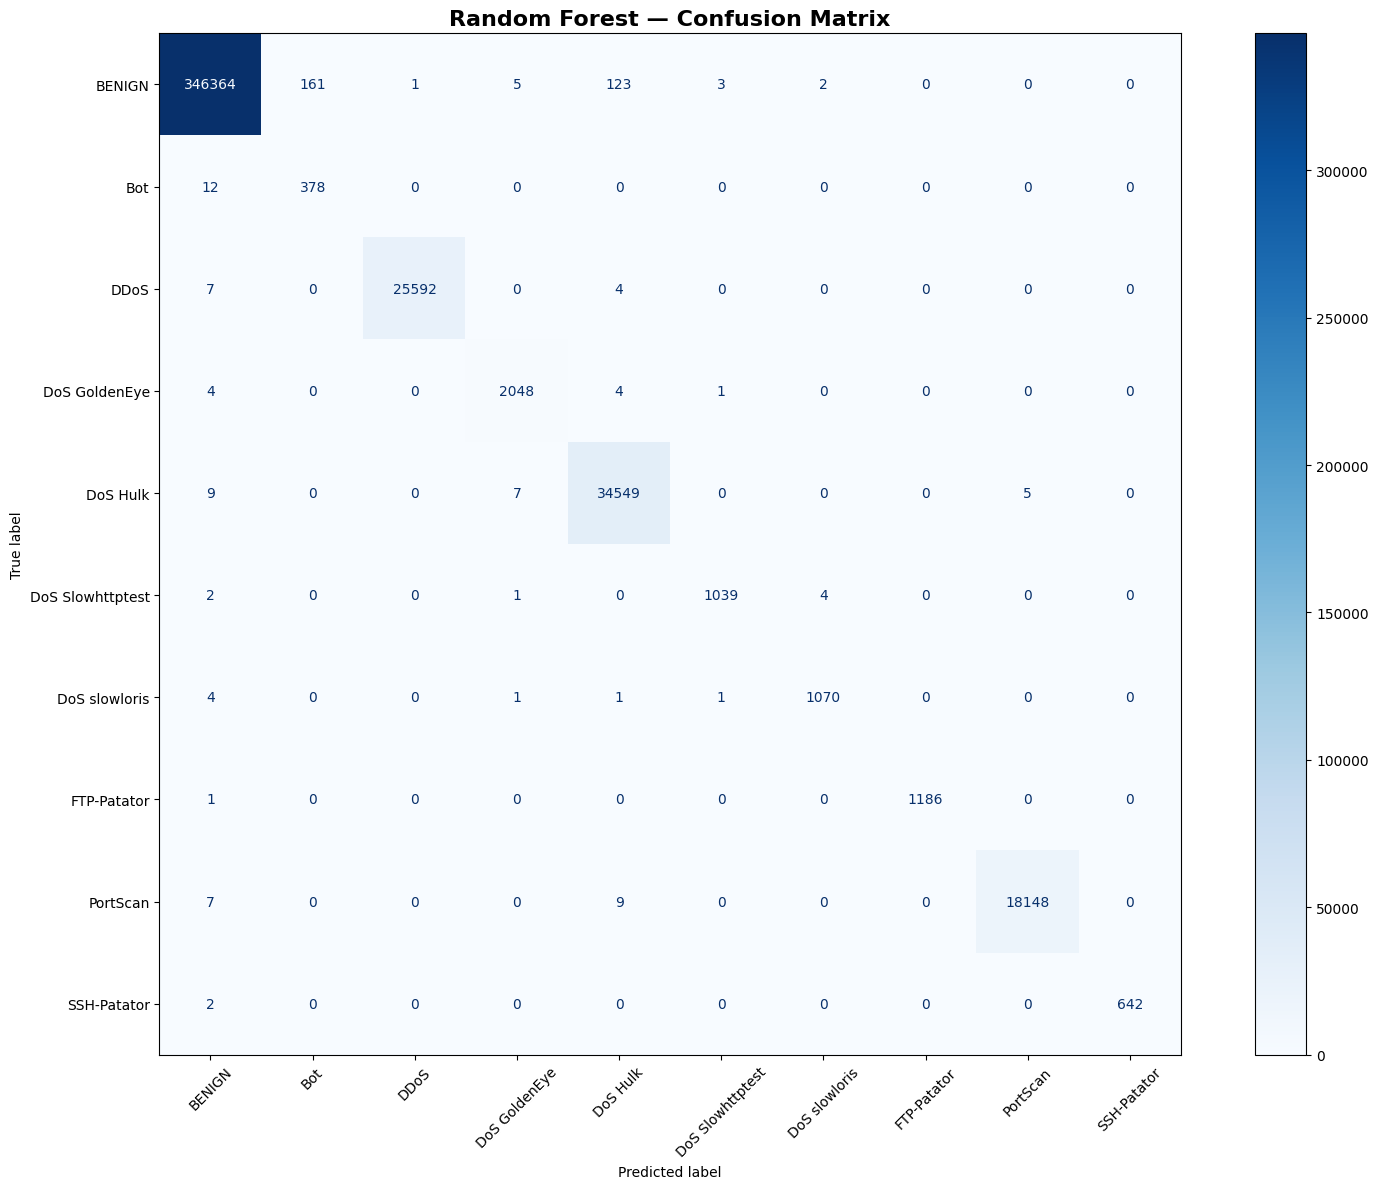

✅ Confusion matrix saved to Drive


In [14]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(16, 12))
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
plt.title('Random Forest — Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'rf_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved to Drive")

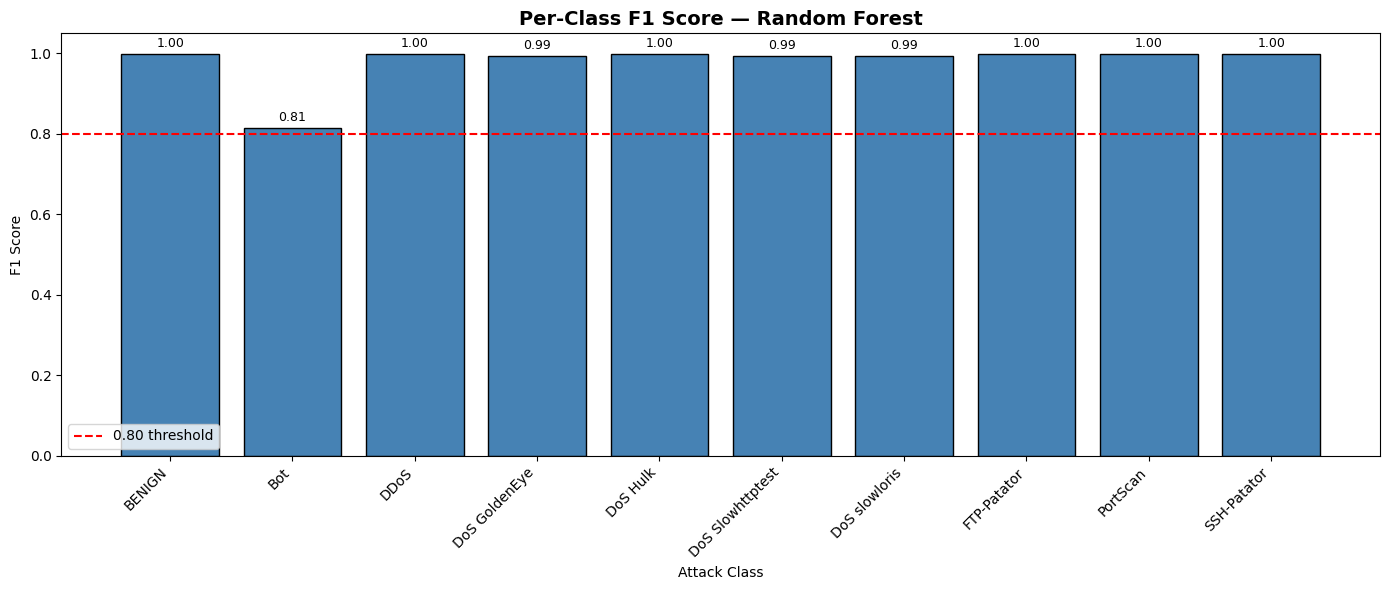

✅ Per-class F1 chart saved to Drive


In [15]:
from sklearn.metrics import f1_score

per_class_f1 = f1_score(y_test, y_pred, average=None)

plt.figure(figsize=(14, 6))
bars = plt.bar(le.classes_, per_class_f1, color='steelblue', edgecolor='black')
plt.axhline(y=0.80, color='red', linestyle='--', label='0.80 threshold')
plt.title('Per-Class F1 Score — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Attack Class')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.legend()

# Annotate bars with values
for bar, val in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(BASE + 'rf_per_class_f1.png', dpi=150)
plt.show()
print("✅ Per-class F1 chart saved to Drive")

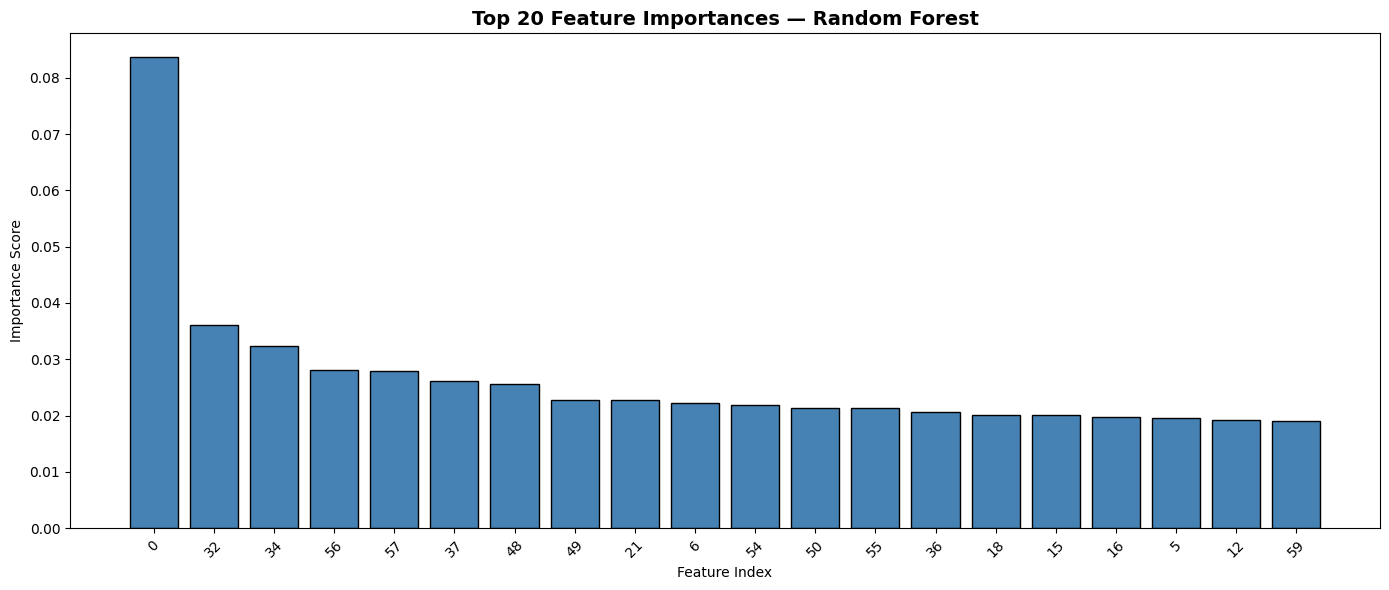

Top 20 most important feature indices:
  Rank  1 — Feature    0 : 0.08369
  Rank  2 — Feature   32 : 0.03611
  Rank  3 — Feature   34 : 0.03232
  Rank  4 — Feature   56 : 0.02803
  Rank  5 — Feature   57 : 0.02796
  Rank  6 — Feature   37 : 0.02606
  Rank  7 — Feature   48 : 0.02568
  Rank  8 — Feature   49 : 0.02275
  Rank  9 — Feature   21 : 0.02272
  Rank 10 — Feature    6 : 0.02222
  Rank 11 — Feature   54 : 0.02189
  Rank 12 — Feature   50 : 0.02138
  Rank 13 — Feature   55 : 0.02137
  Rank 14 — Feature   36 : 0.02063
  Rank 15 — Feature   18 : 0.02006
  Rank 16 — Feature   15 : 0.02005
  Rank 17 — Feature   16 : 0.01971
  Rank 18 — Feature    5 : 0.01959
  Rank 19 — Feature   12 : 0.01919
  Rank 20 — Feature   59 : 0.01896

✅ Feature importance plot saved to Drive


In [16]:
importances  = rf.feature_importances_
top_indices  = np.argsort(importances)[::-1][:20]
top_scores   = importances[top_indices]

plt.figure(figsize=(14, 6))
plt.bar(range(20), top_scores, color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Feature Index')
plt.ylabel('Importance Score')
plt.xticks(range(20), top_indices, rotation=45)
plt.tight_layout()
plt.savefig(BASE + 'rf_feature_importance.png', dpi=150)
plt.show()

print("Top 20 most important feature indices:")
for rank, idx in enumerate(top_indices):
    print(f"  Rank {rank+1:>2} — Feature {idx:>4} : {importances[idx]:.5f}")

print("\n✅ Feature importance plot saved to Drive")

learning curve( is the model actually learning or is ti just memorizing